## Exploratory Data Analysis

This notebook handles the analysis of data to generate key insights from it which will be useful in the modeling part of the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the cleaned diabetes dataset
df = pd.read_csv('../outputs/diabetes_clean.csv', keep_default_na=False)

# Define numerical and categorical columns for analysis
num_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'total_prior_visits',
    'num_med_changes'
]

cat_cols = [
    'race', 'gender', 'age_group', 'diag_1',
    'max_glu_serum', 'A1Cresult', 'insulin',
    'admission_type_id', 'discharge_disposition_id', 'admission_source_id'
]

print(df.shape)
df.head()

(69973, 32)


,race,gender,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,...,glyburide,pioglitazone,rosiglitazone,insulin,readmitted,specialty_known,total_prior_visits,num_med_changes,A1C_tested,age_group
0,Caucasian,Female,2,1,4,13,68,2,28,0,...,No,No,No,Steady,0,0,0,0,0,senior
1,Caucasian,Female,3,3,4,12,33,3,18,0,...,No,No,Steady,Steady,0,1,0,0,0,senior
2,Caucasian,Male,1,1,7,1,51,0,8,0,...,No,No,No,Steady,0,0,0,0,0,middle
3,AfricanAmerican,Female,1,1,7,9,47,2,17,0,...,No,No,No,Steady,0,0,0,0,0,middle
4,Caucasian,Male,2,1,2,3,31,6,16,0,...,No,No,No,Steady,0,0,0,0,0,middle


### Target variable analysis

In [3]:
counts = df['readmitted'].value_counts()
percent = df['readmitted'].value_counts(normalize=True).mul(100).round(1)
print(counts)
print(percent)

readmitted
0    63696
1     6277
Name: count, dtype: int64
readmitted
0    91.0
1     9.0
Name: proportion, dtype: float64


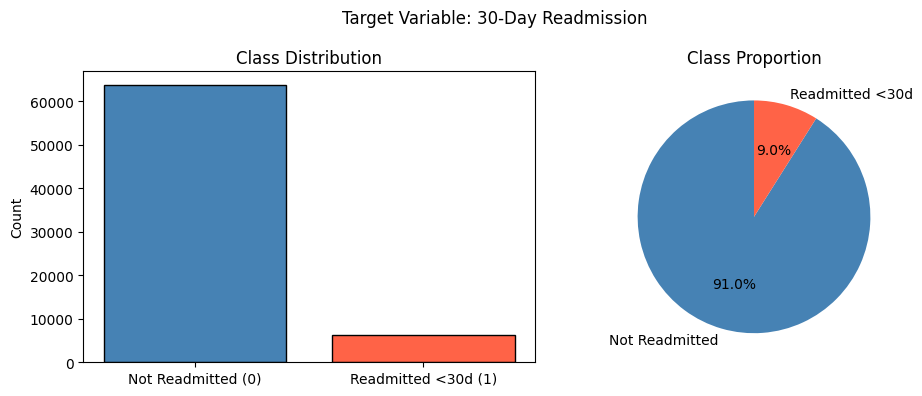

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Not Readmitted (0)', 'Readmitted <30d (1)'], counts.values, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=['Not Readmitted', 'Readmitted <30d'], autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Class Proportion')

plt.suptitle('Target Variable: 30-Day Readmission')
plt.tight_layout()
plt.show()

91% of patients were not readmitted within 30 days. This extreme class imbalance means accuracy is a misleading metric. A model that predicts "not readmitted" for every patient achieves 91% accuracy while being completely useless. AUC, F1-score, and Recall will be used for all model evaluation in Notebook 03.

### Univariate Analysis - Numerical Features

In [5]:
df[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,69973.0,4.27,2.93,1.0,2.0,3.0,6.0,14.0
num_lab_procedures,69973.0,42.88,19.89,1.0,31.0,44.0,57.0,132.0
num_procedures,69973.0,1.43,1.76,0.0,0.0,1.0,2.0,6.0
num_medications,69973.0,15.67,8.29,1.0,10.0,14.0,20.0,81.0
number_outpatient,69973.0,0.28,1.06,0.0,0.0,0.0,0.0,42.0
number_emergency,69973.0,0.10,0.51,0.0,0.0,0.0,0.0,42.0
number_inpatient,69973.0,0.18,0.60,0.0,0.0,0.0,0.0,12.0
number_diagnoses,69973.0,7.22,2.00,1.0,6.0,8.0,9.0,16.0
total_prior_visits,69973.0,0.56,1.43,0.0,0.0,0.0,1.0,49.0
num_med_changes,69973.0,0.26,0.47,0.0,0.0,0.0,0.0,4.0


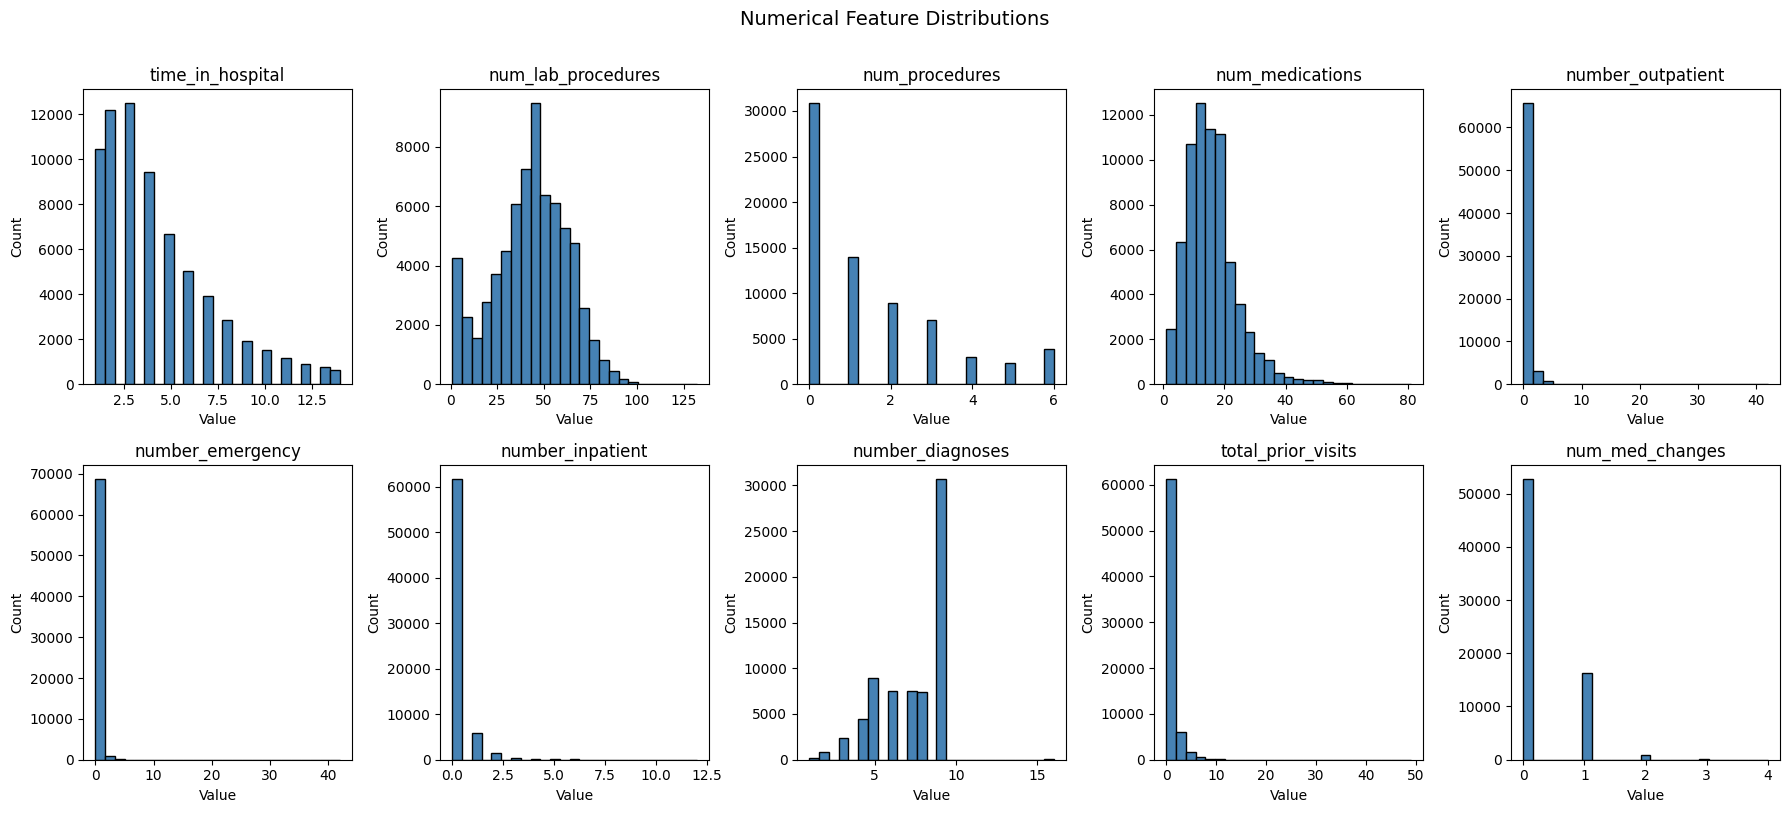

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=25, edgecolor='black', color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Numerical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

`number_outpatient`, `number_emergency`, and `number_inpatient` are all heavily right-skewed. Most patients have 0 prior visits but a small number have many. `total_prior_visits` inherits this skew. `num_med_changes` is concentrated at 0-1 for most patients. `time_in_hospital` is bounded 1-14 by dataset design but shows a clear right-skewed distribution, with the vast majority of patients staying between 2 to 6 days. These skewed distributions mean tree-based models will handle them more naturally than linear models, which may require scaling or transformations

### Univariate Analysis - Categorical Features

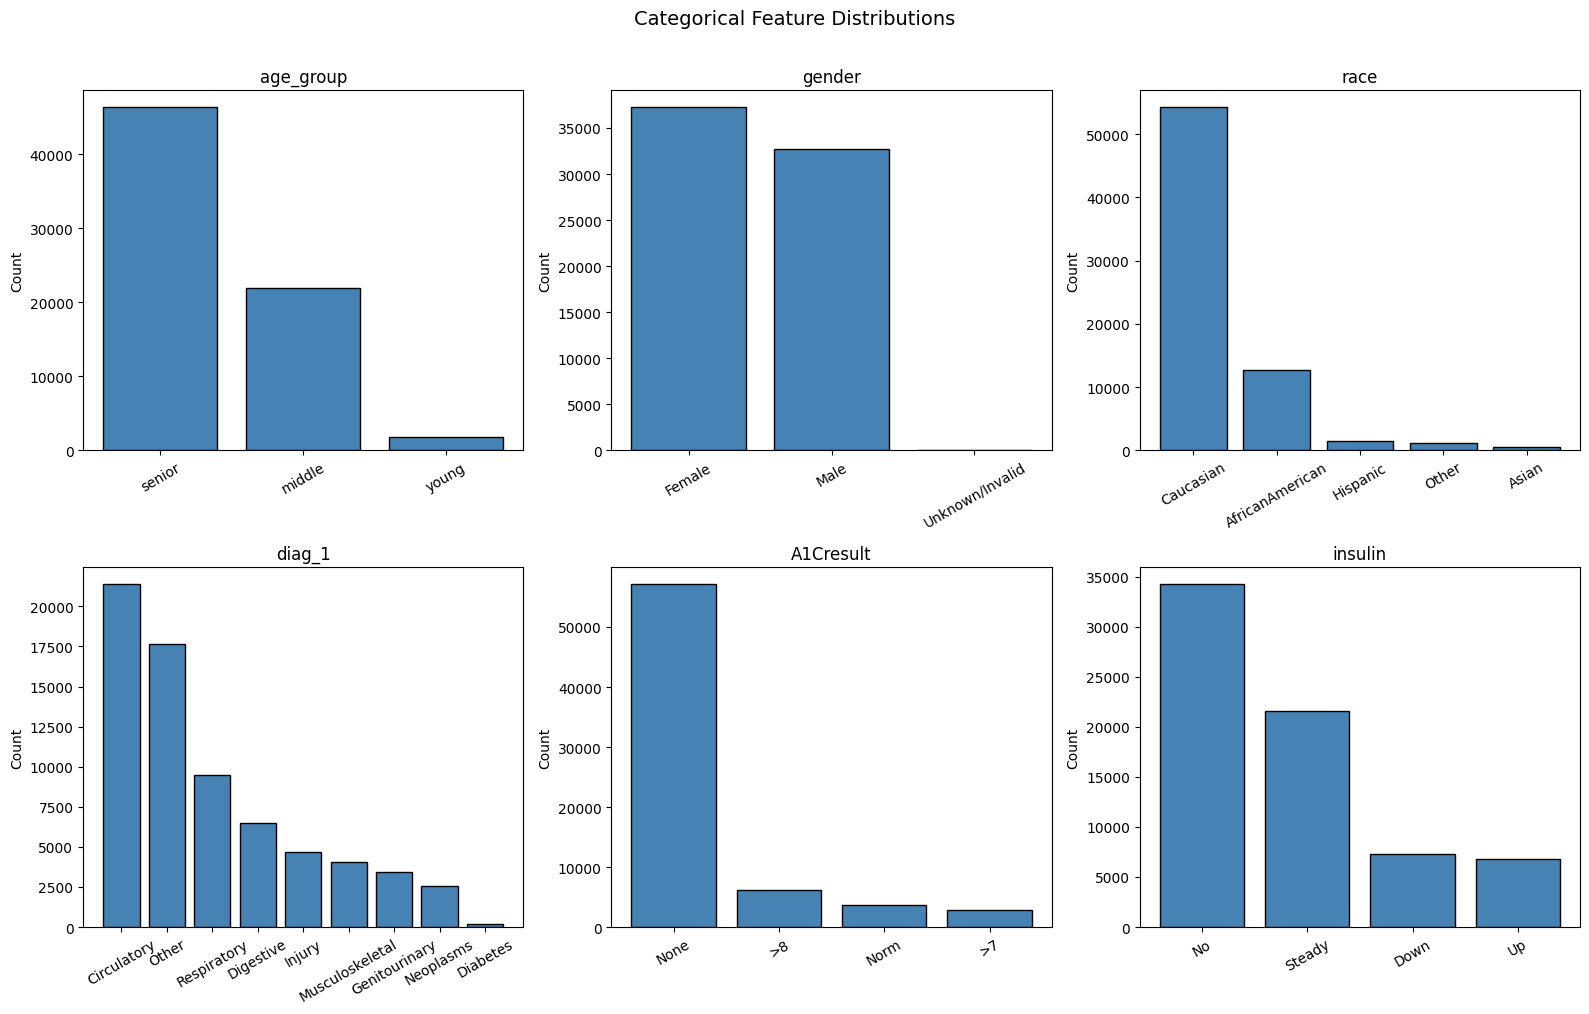

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plot_cats = ['age_group', 'gender', 'race', 'diag_1', 'A1Cresult', 'insulin']

for i, col in enumerate(plot_cats):
    vc = df[col].value_counts()
    axes[i].bar(vc.index, vc.values, edgecolor='black', color='steelblue')
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Categorical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

We plotted 6 out of the 10 categorical columns defined at the top. The remaining 4 (admission_type_id, discharge_disposition_id, admission_source_id, max_glu_serum) are analyzed separately later because they need more context to interpret properly. discharge_disposition_id for example has 12+ categories and is the strongest predictor so it gets its own dedicated section.

From the 6 plotted columns:
- age_group: senior patients (60+) are the overwhelming majority. middle-aged patients are second. young patients (under 30) are very few. This is expected since diabetic complications requiring hospitalization are more common in older adults.
- gender: female patients slightly outnumber male patients. The split is roughly even.
- race: Caucasian patients are the largest group by a wide margin followed by AfricanAmerican. Asian and Hispanic patients are a small minority. This reflects the demographics of the 130 US hospitals in the dataset from 1999 to 2008.
- diag_1: Circulatory disease is the most common primary diagnosis. Other is second. Injury is third. Diabetes as a primary diagnosis is the least common, appearing at the bottom of the chart. This does not mean diabetes is rare in the dataset -- all patients are diabetic -- it means most patients were admitted primarily for something else like heart disease or injury, with diabetes as a secondary condition.
- A1Cresult: None (test not performed) is by far the largest category with around 57,000 of 69,973 patients having no HbA1c test done. This is 81.6% of patients. Among the tested groups, >8 is the largest followed by Norm and then >7. This directly confirms the paper's finding that HbA1c testing was rare during inpatient diabetic encounters.
- insulin: Steady is the most common value meaning most patients who received insulin had no dosage change. No is second meaning many patients did not receive insulin at all. Up and Down are much smaller.

### Bivariate Analysis - Numerical Features vs Target

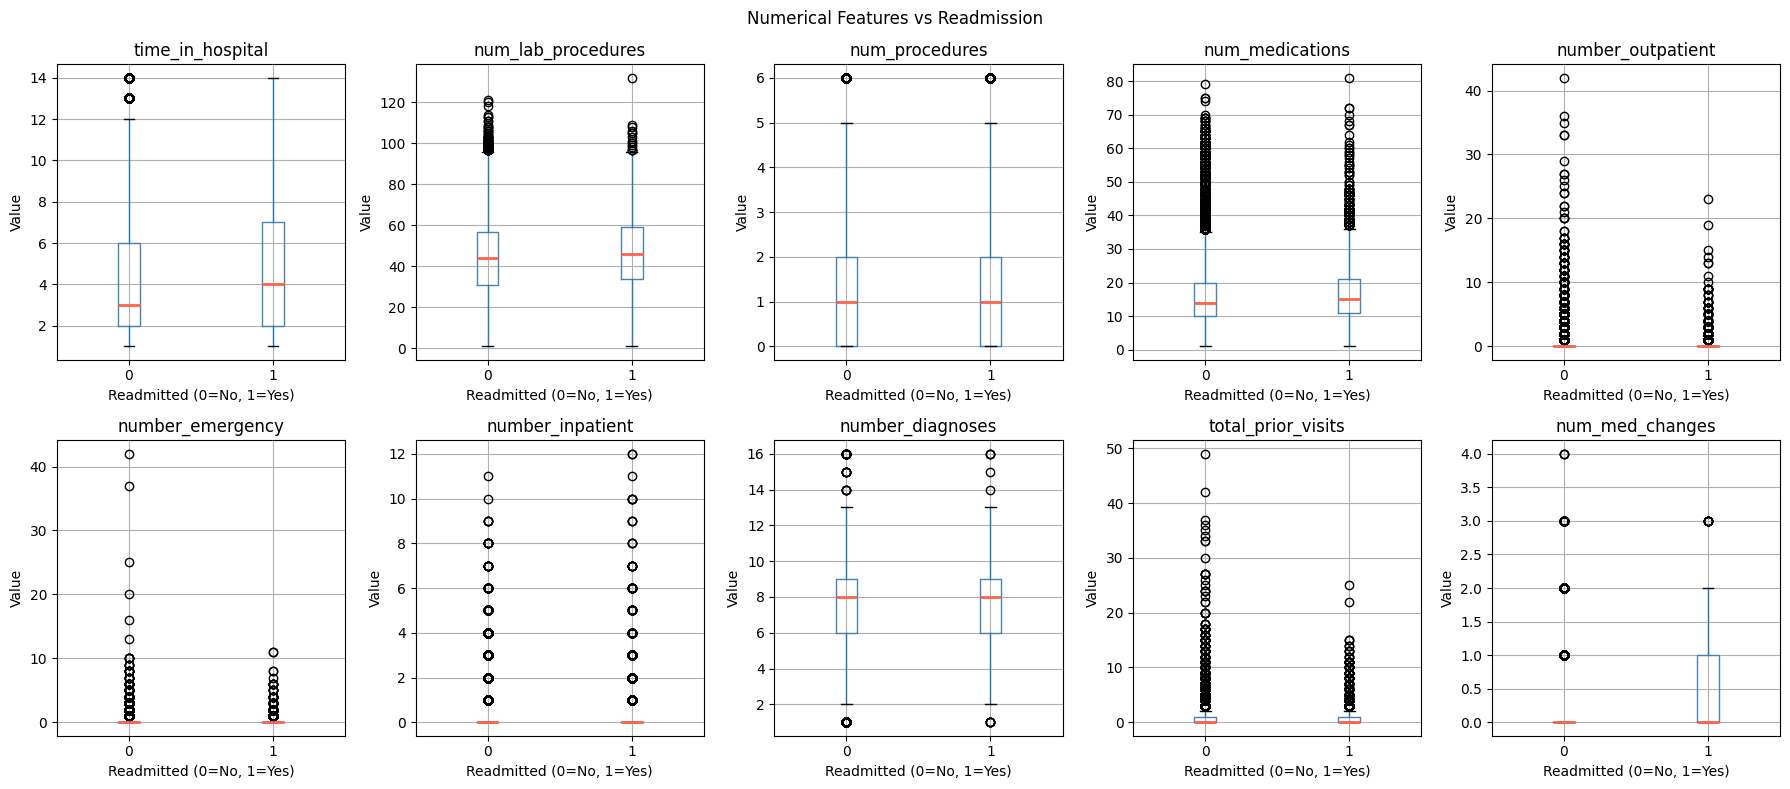

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='readmitted', ax=axes[i], boxprops=dict(color='steelblue'), medianprops=dict(color='tomato', linewidth=2))
    axes[i].set_title(col)
    axes[i].set_xlabel('Readmitted (0=No, 1=Yes)')
    axes[i].set_ylabel('Value')

plt.suptitle('Numerical Features vs Readmission')
plt.tight_layout()
plt.show()

#### Visible difference
- time_in_hospital: Patients who were readmitted generally had longer initial hospital stays. The median for Group 1 is visibly higher (around 4 days) compared to Group 0 (around 3 days). The upper quartile also stretches further up for readmitted patients.
- num_medications: Readmitted patients tend to be administered slightly more medications during their stay, as indicated by a slightly higher median and a higher overall box placement.
- num_med_changes: While the median for both groups is 0, the top of the box (the 75th percentile) reaches 1 for Group 1, whereas it remains at 0 for Group 0. This suggests that readmitted patients were more likely to experience at least one medication change

#### Minimal Difference
- num_procedures & number_diagnoses: The medians and the boxes are practically identical between Group 0 and Group 1.
- num_lab_procedures: The distributions are very similar. Group 1 might have a marginally higher median, but the overlap is substantial.

This suggests these features may not be very good predictors

#### Heavy Outliers

number_outpatient, number_emergency, number_inpatient, and total_prior_visits: For all these historical visit metrics, the vast majority of patients in both groups had 0 prior visits.

Interesting visual note: For number_emergency and total_prior_visits, the most extreme high outliers actually belong to patients who were not readmitted (Group 0). However, because the data is so heavily skewed toward zero, a boxplot is not the best tool for spotting differences in averages here

In [9]:
mean_by_class = df.groupby('readmitted')[num_cols].mean().T.round(3)
mean_by_class.columns = ['Not Readmitted', 'Readmitted <30d']
mean_by_class['Difference'] = (mean_by_class['Readmitted <30d'] - mean_by_class['Not Readmitted']).round(3)
mean_by_class['% Difference'] = ((mean_by_class['Difference'] / mean_by_class['Not Readmitted']) * 100).round(1)
mean_by_class.sort_values('% Difference', ascending=False)

,Not Readmitted,Readmitted <30d,Difference,% Difference
number_inpatient,0.157,0.369,0.212,135.0
total_prior_visits,0.533,0.827,0.294,55.2
number_emergency,0.099,0.150,0.051,51.5
num_med_changes,0.258,0.296,0.038,14.7
time_in_hospital,4.222,4.797,0.575,13.6
number_outpatient,0.277,0.308,0.031,11.2
num_medications,15.571,16.626,1.055,6.8
num_lab_procedures,42.675,44.915,2.240,5.2
number_diagnoses,7.195,7.513,0.318,4.4
num_procedures,1.426,1.425,-0.001,-0.1


Looking at the % Difference column which shows how much higher the mean is for readmitted patients compared to non-readmitted:

- number_inpatient has the largest difference at 135%. Readmitted patients had on average 0.369 prior inpatient visits vs 0.157 for non-readmitted. This is the strongest signal in numerical features and matches the paper's finding.
- total_prior_visits is second at 55.2% but this is expected since number_inpatient is one of its three components. It is not an independent signal.
- number_emergency is third at 51.5%. Patients with more emergency visits before this admission are more likely to be readmitted, suggesting a pattern of unstable health.
- time_in_hospital shows a 13.6% difference. Readmitted patients stayed slightly longer on average (4.8 days vs 4.2 days).
- num_procedures shows essentially no difference (-0.1%). Procedures done during this visit do not distinguish readmitted from non-readmitted patients.
- Boxplots will show large overlap between classes for all features since correlations are weak. This is normal for this dataset and is why we need multiple features combined in a model rather than any single one.

### Bivariate Analysis - Categorical Features vs Target

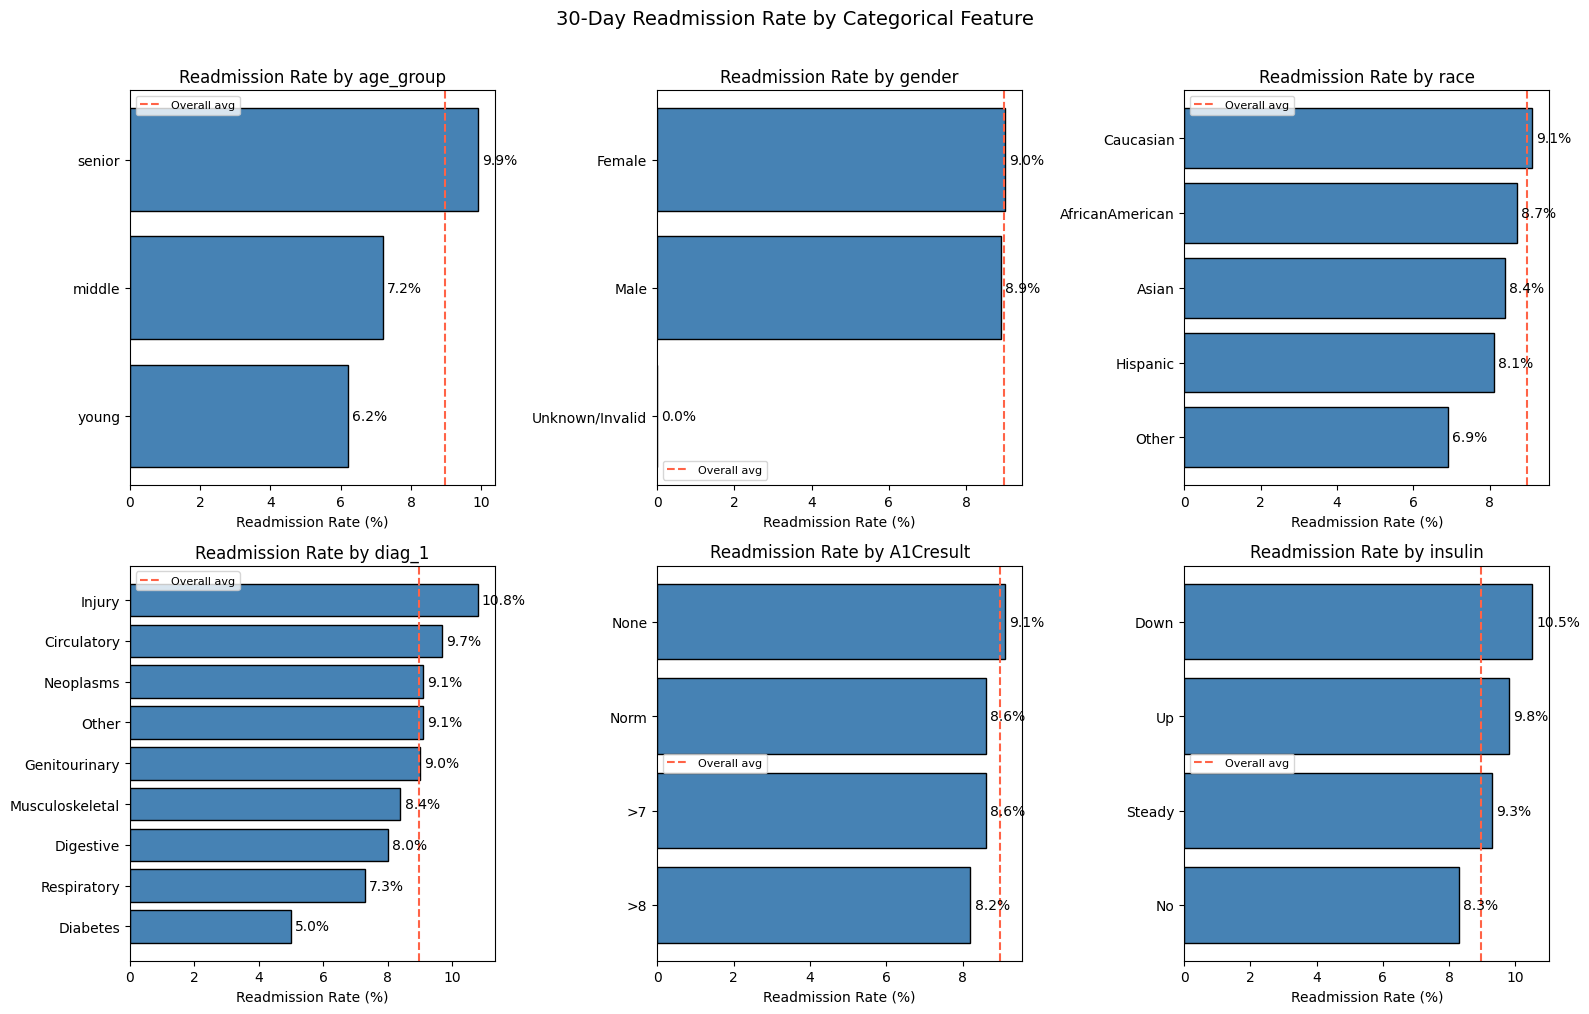

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plot_cats = ['age_group', 'gender', 'race', 'diag_1', 'A1Cresult', 'insulin']

for i, col in enumerate(plot_cats):
    rates = df.groupby(col, observed=True)['readmitted'].mean().mul(100).round(1).sort_values()
    bars = axes[i].barh(rates.index, rates.values, edgecolor='black', color='steelblue')
    axes[i].bar_label(bars, fmt='%.1f%%', padding=3)
    axes[i].axvline(df['readmitted'].mean() * 100, color='tomato', linestyle='--', linewidth=1.5, label='Overall avg')
    axes[i].set_title(f'Readmission Rate by {col}')
    axes[i].set_xlabel('Readmission Rate (%)')
    axes[i].legend(fontsize=8)

plt.suptitle('30-Day Readmission Rate by Categorical Feature', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

The red dashed line is the 9% overall readmission baseline. Key findings from each chart:

- age_group: senior patients (60+) have the highest readmission rate at 9.92%, slightly above the baseline. Middle-aged patients are below baseline at 7.19% and young patients are the lowest at 6.19%. This is expected as older patients have more comorbidities and more complex health conditions that make recovery harder.
- gender: male (8.91%) and female (9.03%) readmission rates are nearly identical and both very close to the overall average. Gender is not a meaningful predictor.
- race: rates are similar across racial groups. Caucasian is slightly highest at 9.12% and Other is lowest at 6.87%. Differences are small. This will be examined more carefully in the planned fairness analysis for the IBCAST paper where we check whether model errors are distributed unevenly across racial groups even if raw rates look similar.
- diag_1: Diabetes as a primary diagnosis has the lowest readmission rate at 5.00%, well below the 9% baseline. Injury has the highest at 10.78%. Circulatory disease is above baseline at 9.67%. See the dedicated section below for more detail.
- A1Cresult: the None group (81.6% of patients, test not done) has a readmission rate of 9.10%, which is slightly above the 9% baseline and higher than all three tested groups. Norm is 8.63%, >7 is 8.59% and >8 is 8.16%. Patients who were tested had lower readmission rates regardless of the result. See the dedicated HbA1c section for interpretation.
- insulin: patients with insulin dose decreased (Down) have the highest rate at 10.55%, followed by dose increased (Up) at 9.84%, Steady at 9.26% and No insulin at 8.28%. Patients whose insulin was actively adjusted during the visit (either up or down) are above the baseline, suggesting that medication instability during the stay is associated with worse outcomes after discharge.

### HbA1c Result vs Readmission - Paper's Central Hypothesis

In [11]:
a1c_full = df.groupby('A1Cresult', observed=True)['readmitted'].agg(['mean','count'])
a1c_full.columns = ['Readmission Rate', 'Count']
a1c_full['Readmission Rate (%)'] = (a1c_full['Readmission Rate'] * 100).round(2)
a1c_full = a1c_full[['Count', 'Readmission Rate (%)']].sort_values('Readmission Rate (%)', ascending=False)
print("HbA1c Result vs 30-Day Readmission (all groups including None):")
print(a1c_full)
print(f"\nTotal accounted for: {a1c_full['Count'].sum()}")
print(f"Overall readmission rate: {df['readmitted'].mean()*100:.2f}%")

HbA1c Result vs 30-Day Readmission (all groups including None):
           Count  Readmission Rate (%)
A1Cresult                             
None       57128                  9.10
Norm        3741                  8.63
>7          2865                  8.59
>8          6239                  8.16

Total accounted for: 69973
Overall readmission rate: 8.97%


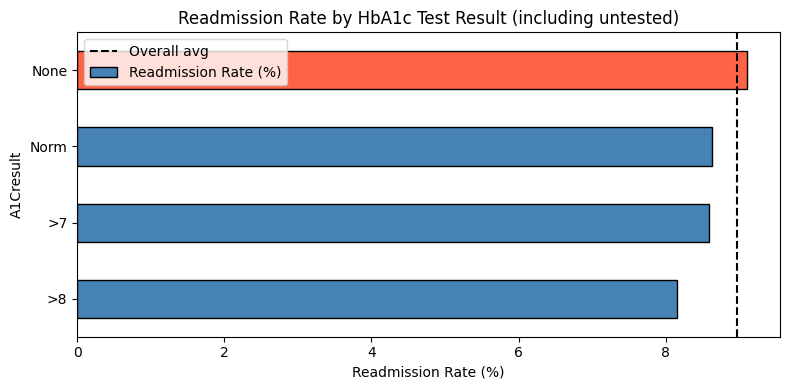

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
rates = a1c_full['Readmission Rate (%)'].sort_values()
colors = ['tomato' if v > df['readmitted'].mean() * 100 else 'steelblue' for v in rates.values]
rates.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.axvline(df['readmitted'].mean() * 100, color='black', linestyle='--', linewidth=1.5, label='Overall avg')
ax.set_title('Readmission Rate by HbA1c Test Result (including untested)')
ax.set_xlabel('Readmission Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

All four A1Cresult groups have rates very close to the 9% baseline. The key finding is:

The None group (57,128 patients, 81.6% of the dataset) has a readmission rate of 9.10%. All three tested groups are below this: Norm at 8.63%, >7 at 8.59%, and >8 at 8.16%. This means patients who had their HbA1c tested had slightly lower readmission rates than untested patients, regardless of whether the result was normal or dangerously high.

The >8 group having the lowest rate of all four groups appears counterintuitive since >8 means dangerously uncontrolled blood sugar. The paper's explanation is that a very high HbA1c result is more likely to trigger active medication changes by the doctor. Those medication changes appear to reduce readmission. This is why the paper found that the combination of testing plus medication change reduces readmission more than testing alone.

However, all differences here are very small (less than 1 percentage point across all groups). A1Cresult alone is a weak predictor of readmission, which is confirmed by its low Cramer's V of 0.0102 in the correlation section. The predictive value of HbA1c comes from its interaction with medication change, not from the raw result value alone.

### Discharge Disposition vs Readmission

In [13]:
disp_rates = df.groupby('discharge_disposition_id')['readmitted'].mean().mul(100).round(1)
disp_counts = df['discharge_disposition_id'].value_counts()

disp_summary = pd.DataFrame({
    'Count': disp_counts,
    'Readmission Rate (%)': disp_rates
}).sort_values('Readmission Rate (%)', ascending=False)

print("Discharge Disposition by Readmission Rate (top 10):")
print(disp_summary.head(10))
print()
print("Most common disposition IDs (by count):")
print(disp_summary.sort_values('Count', ascending=False).head(5))

Discharge Disposition by Readmission Rate (top 10):
                          Count  Readmission Rate (%)
discharge_disposition_id                             
12                            2                  50.0
15                           40                  45.0
28                           90                  35.6
22                         1410                  26.3
9                             9                  22.2
5                           913                  20.6
2                          1539                  13.8
3                          8784                  13.4
4                           541                  10.4
18                         2474                  10.1

Most common disposition IDs (by count):
                          Count  Readmission Rate (%)
discharge_disposition_id                             
1                         44317                   6.9
3                          8784                  13.4
6                          8289            

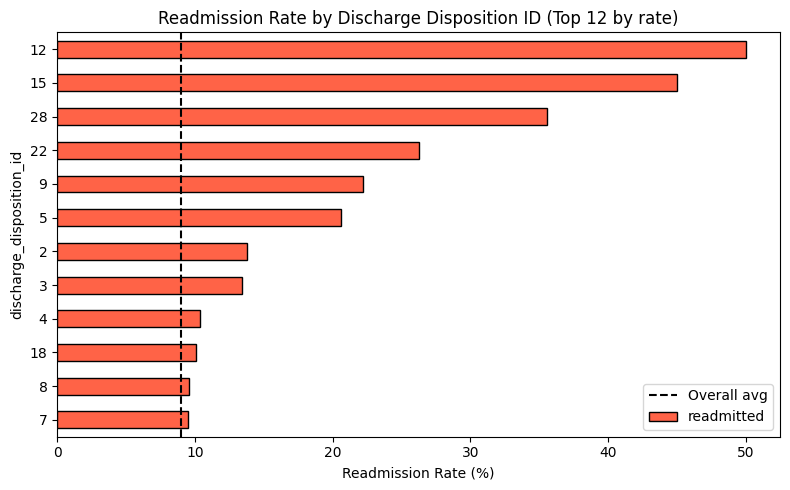

In [14]:
top_disp = disp_rates.sort_values(ascending=False).head(12).sort_values()

colors = ['tomato' if v > df['readmitted'].mean() * 100 else 'steelblue' for v in top_disp.values]

plt.figure(figsize=(8, 5))
top_disp.plot(kind='barh', color=colors, edgecolor='black')
plt.axvline(df['readmitted'].mean() * 100, color='black', linestyle='--', linewidth=1.5, label='Overall avg')
plt.title('Readmission Rate by Discharge Disposition ID (Top 12 by rate)')
plt.xlabel('Readmission Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

discharge_disposition_id has the highest Cramer's V of all categorical features meaning it has the strongest association with readmission. Using the IDs_mapping.csv file to map IDs to descriptions:

- IDs 12, 15, 28 have very high readmission rates (35 to 50%) but very low counts (2, 40 and 90 patients). These are edge cases and not clinically actionable at scale.
- ID 22 (rehab facility) has 26.3% rate with 1,410 patients. A meaningful high-risk group.
- ID 5 (another inpatient care facility) has 20.6% rate with 913 patients.
- ID 2 (short-term hospital transfer) has 13.8% rate with 1,539 patients.
- ID 3 (skilled nursing facility) has 13.4% rate with 8,784 patients. This is the largest high-risk group and the most clinically important given its size.
- ID 1 (discharged to home) is the most common disposition with 44,317 patients and has a readmission rate of 6.9%, well below the 9% baseline.
- ID 6 (home with home health service) has 8,289 patients at 9.5%, close to baseline.

The pattern is consistent: patients transferred to another facility rather than sent home are more likely to be readmitted within 30 days. This makes clinical sense as these patients were too unwell to go home directly.

### Admission Type vs Readmission

In [15]:
admit_rates = df.groupby('admission_type_id')['readmitted'].mean().mul(100).round(1)
admit_counts = df['admission_type_id'].value_counts()

admit_summary = pd.DataFrame({
    'Count': admit_counts,
    'Readmission Rate (%)': admit_rates
}).sort_values('Readmission Rate (%)', ascending=False)

print("Admission Type by Readmission Rate:")
print(admit_summary)

Admission Type by Readmission Rate:
                   Count  Readmission Rate (%)
admission_type_id                             
4                      9                  11.1
6                   4516                  10.0
1                  35466                   9.2
2                  12802                   9.0
5                   3086                   8.6
3                  13785                   8.3
8                    291                   7.2
7                     18                   0.0


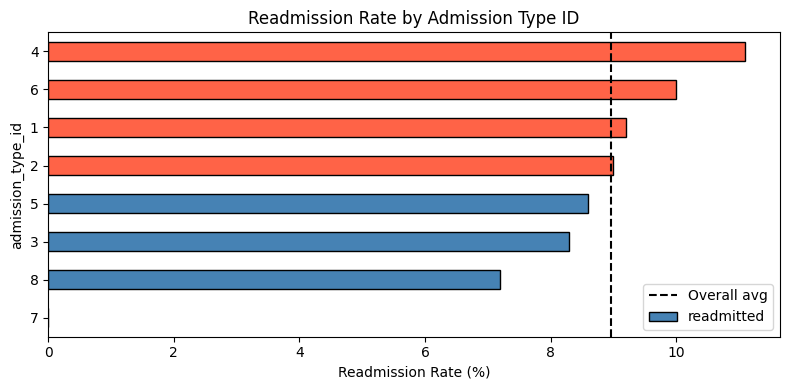

In [16]:
top_admit = admit_rates.sort_values(ascending=False).sort_values()
colors = ['tomato' if v > df['readmitted'].mean() * 100 else 'steelblue'
          for v in top_admit.values]

plt.figure(figsize=(8, 4))
top_admit.plot(kind='barh', color=colors, edgecolor='black')
plt.axvline(df['readmitted'].mean() * 100, color='black', linestyle='--', linewidth=1.5, label='Overall avg')
plt.title('Readmission Rate by Admission Type ID')
plt.xlabel('Readmission Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

admission_type_id maps to the reason the patient was admitted. Using the IDs_mapping.csv descriptions:

- ID 1 (Emergency) is the most common admission type. Emergency admissions tend to represent patients in acute crisis and show higher readmission rates than elective ones.
- ID 2 (Urgent) is also above baseline. Urgent admissions share similar characteristics to emergency ones.
- ID 3 (Elective) represents planned admissions, typically for procedures or scheduled treatment. These patients tend to be more stable and have lower readmission rates.
- IDs 5, 6, 7, 8 represent Not Available, NULL, Trauma, and Newborn categories respectively. Some of these have very low counts and their rates should be interpreted with caution.
- ID 4 (ICF / nursing facility) has a 10.4% rate with 541 patients, reinforcing the risk associated with non-home discharges.

The pattern makes clinical sense: unplanned admissions (emergency and urgent) are associated with more unstable patient conditions, which correlates with higher readmission risk.

### Admission Source vs Readmission

In [17]:
source_rates = df.groupby('admission_source_id')['readmitted'].mean().mul(100).round(1)
source_counts = df['admission_source_id'].value_counts()

source_summary = pd.DataFrame({
    'Count': source_counts,
    'Readmission Rate (%)': source_rates
}).sort_values('Readmission Rate (%)', ascending=False)

print("Admission Source by Readmission Rate (top 10):")
print(source_summary.head(10))
print()
print("Most common source IDs (by count):")
print(source_summary.sort_values('Count', ascending=False).head(5))

Admission Source by Readmission Rate (top 10):
                     Count  Readmission Rate (%)
admission_source_id                             
3                      136                  14.0
20                     153                  13.7
5                      512                   9.4
7                    37260                   9.2
8                       11                   9.1
2                      908                   8.9
17                    4820                   8.8
1                    21746                   8.6
4                     2530                   8.5
9                       95                   8.4

Most common source IDs (by count):
                     Count  Readmission Rate (%)
admission_source_id                             
7                    37260                   9.2
1                    21746                   8.6
17                    4820                   8.8
4                     2530                   8.5
6                     1785         

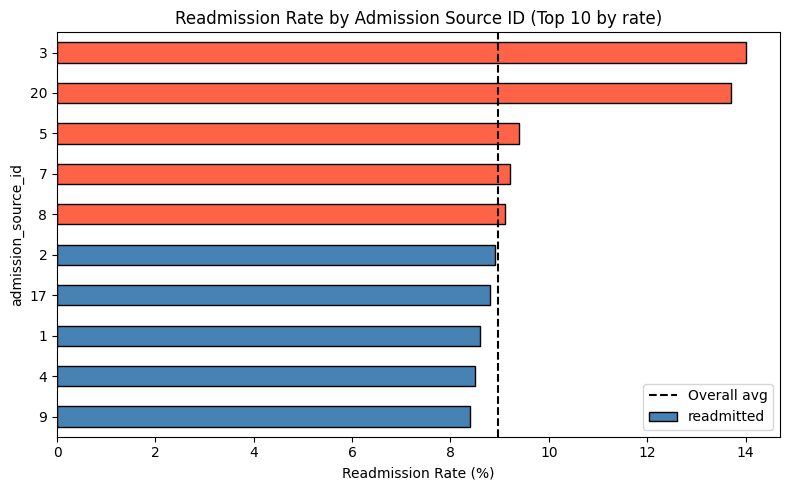

In [18]:
top_source = source_rates.sort_values(ascending=False).head(10).sort_values()
colors = ['tomato' if v > df['readmitted'].mean() * 100 else 'steelblue' for v in top_source.values]

plt.figure(figsize=(8, 5))
top_source.plot(kind='barh', color=colors, edgecolor='black')
plt.axvline(df['readmitted'].mean() * 100, color='black', linestyle='--', linewidth=1.5, label='Overall avg')
plt.title('Readmission Rate by Admission Source ID (Top 10 by rate)')
plt.xlabel('Readmission Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

admission_source_id records where the patient came from before being admitted. Key IDs from the mapping:

- ID 7 (Emergency room) is the most common source. Patients coming through the ER tend to have above-average readmission rates since their condition was acute enough to require emergency care first.
- ID 1 (Physician referral) represents planned admissions from a doctor's office. These patients are typically more stable with lower readmission rates.
- ID 4 (Transfer from a hospital) and ID 2 (Transfer from another healthcare facility) tend to have higher rates. Patients being transferred between facilities are often more complex cases.
- ID 17 and ID 20 may correspond to NULL or Not Available categories with very few patients. Their rates should not be over-interpreted.
- ID 3 (Transfer from a Skilled Nursing Facility) shows a highly significant readmission rate of 14.0%. Patients arriving from a nursing home are likely frail, older, and have complex comorbidities, explaining this high risk.

The admission source complements the admission type: together they describe both the urgency and the origin of the encounter, both of which carry signal about how sick the patient was at the time of admission.

### Blood Glucose Serum Test vs Readmission

In [19]:
glu_rates = df.groupby('max_glu_serum')['readmitted'].mean().mul(100).round(2)
glu_counts = df['max_glu_serum'].value_counts()

glu_summary = pd.DataFrame({
    'Count': glu_counts,
    'Readmission Rate (%)': glu_rates
}).sort_values('Readmission Rate (%)', ascending=False)

print("Blood Glucose Serum Result vs 30-Day Readmission:")
print(glu_summary)
print(f"\nOverall readmission rate: {df['readmitted'].mean()*100:.2f}%")

Blood Glucose Serum Result vs 30-Day Readmission:
               Count  Readmission Rate (%)
max_glu_serum                             
>200             936                 10.90
>300             712                 10.11
Norm            1700                  9.76
None           66625                  8.91

Overall readmission rate: 8.97%


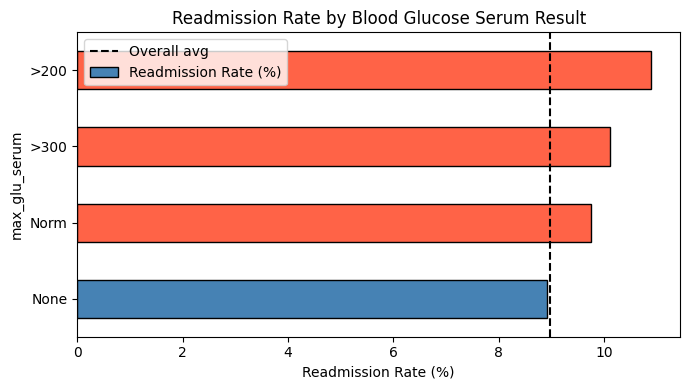

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
rates = glu_summary['Readmission Rate (%)'].sort_values()
colors = ['tomato' if v > df['readmitted'].mean() * 100 else 'steelblue' for v in rates.values]
rates.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.axvline(df['readmitted'].mean() * 100, color='black', linestyle='--', linewidth=1.5, label='Overall avg')
ax.set_title('Readmission Rate by Blood Glucose Serum Result')
ax.set_xlabel('Readmission Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

max_glu_serum records the result of a blood glucose test taken during the encounter. Unlike HbA1c which measures average blood sugar over 2-3 months, this is a snapshot of blood sugar at a single point in time.

The distribution shows that the vast majority of patients were not tested (None), similar to A1Cresult. However, the readmission pattern is the exact opposite of HbA1c.
The None group has a readmission rate of 8.91%, which is slightly below the overall 8.97% baseline. The tested groups are all above the baseline: >200 (10.90%), >300 (10.11%), and Norm (9.76%).

This makes clinical sense: a blood glucose serum test measures immediate, acute blood sugar levels. Very high spikes during an inpatient stay are clear signs of acute patient instability, leading to higher short-term readmission risks. Despite this trend, the Cramer's V for max_glu_serum (0.0100) is very low, meaning it is still a weak predictor of readmission on its own.

### Primary Diagnosis vs Readmission

In [21]:
diag_rates = df.groupby('diag_1')['readmitted'].mean().mul(100).round(2).sort_values()
diag_counts = df['diag_1'].value_counts()

diag_summary = pd.DataFrame({
    'Count': diag_counts,
    'Readmission Rate (%)': diag_rates
}).sort_values('Readmission Rate (%)')

print(diag_summary)

                 Count  Readmission Rate (%)
diag_1                                      
Diabetes           200                  5.00
Respiratory       9486                  7.28
Digestive         6487                  8.02
Musculoskeletal   4064                  8.39
Genitourinary     3440                  8.98
Neoplasms         2538                  9.06
Other            17680                  9.07
Circulatory      21384                  9.67
Injury            4694                 10.78


Diabetes as a primary diagnosis (ICD-9: 250.xx) has the lowest readmission rate at 5.0%, well below the 9% baseline. This directly supports the paper's finding. When a patient is admitted primarily because of diabetes, clinical staff pay more attention to diabetic management including HbA1c testing and medication adjustment, which leads to better outcomes after discharge. Because the sample size for primary diabetes admissions is very small (0.2% of the dataset), this 5.0% rate is prone to statistical noise. It is an interesting finding, but it shouldn't be treated with the same weight as the circulatory disease cohort (21,384 patients)

Injury has the highest rate at 10.78%. This makes sense as injury patients may have unstable underlying diabetic control that was not the focus of the admission.

Circulatory disease (the most common primary diagnosis in this dataset) has a 9.67% rate, slightly above baseline. This is the group where the paper found HbA1c measurement had a significantly different effect than in diabetes-primary patients.

Respiratory (7.28%) and Digestive (8.02%) are below the baseline. These conditions when primary may receive more general medical attention that incidentally benefits diabetic management.

### Correlation Analysis - Numerical Features

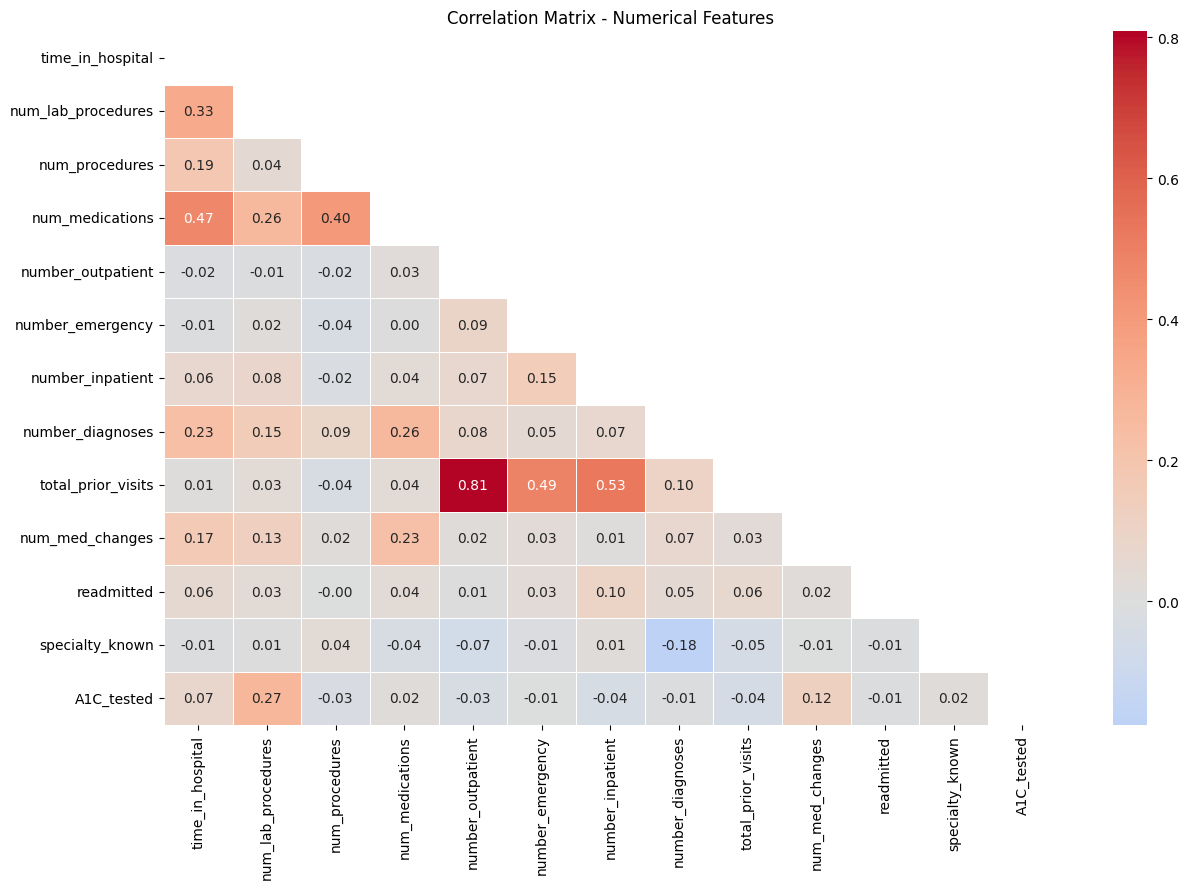

In [22]:
corr_cols = num_cols + ['readmitted', 'specialty_known', 'A1C_tested']
corr = df[corr_cols].corr()

plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, mask=mask, linewidths=0.5)
plt.title('Correlation Matrix - Numerical Features')
plt.tight_layout()
plt.show()

We use Pearson correlation here because all columns in this heatmap are numerical. The readmitted, specialty_known and A1C_tested columns are binary (0/1) but Pearson correlation still works on binary targets and gives the same result as point-biserial correlation.

Key observations:

- number_inpatient has the highest correlation with readmitted (0.10). This is small in absolute terms but is the strongest signal among numerical features in this dataset.
- total_prior_visits shows strong correlation with number_inpatient (above 0.5), number_outpatient and number_emergency because it is their sum. This is expected multicollinearity. For logistic regression, keeping all four could inflate variance. For tree-based models this is not an issue.
- num_medications and num_procedures are moderately correlated with each other (around 0.4). More medications tend to coincide with more clinical procedures.
- num_procedures has near-zero correlation with readmitted (essentially 0.00) confirming it adds no predictive signal for readmission.
- A1C_tested has a small negative correlation with readmitted (-0.01) meaning patients who got tested were very slightly less likely to be readmitted. The effect is tiny.

### Point-Biserial Correlation with Target

In [23]:
pb_results = {}
for col in num_cols + ['specialty_known', 'A1C_tested']:
    corr_val, pval = pointbiserialr(df[col], df['readmitted'])
    pb_results[col] = {
        'Correlation': round(corr_val, 4),
        'P-Value': round(pval, 6),
        'Significant': 'Yes' if pval < 0.05 else 'No'
    }

pb_df = pd.DataFrame(pb_results).T.sort_values('Correlation', ascending=False)
print(pb_df)

                   Correlation   P-Value Significant
number_inpatient        0.1005       0.0         Yes
total_prior_visits      0.0588       0.0         Yes
time_in_hospital        0.0561       0.0         Yes
number_diagnoses        0.0454       0.0         Yes
num_medications         0.0364       0.0         Yes
num_lab_procedures      0.0322       0.0         Yes
number_emergency        0.0281       0.0         Yes
num_med_changes         0.0227       0.0         Yes
number_outpatient       0.0085  0.024149         Yes
num_procedures         -0.0001  0.969451          No
specialty_known        -0.0086  0.022187         Yes
A1C_tested             -0.0096  0.011145         Yes


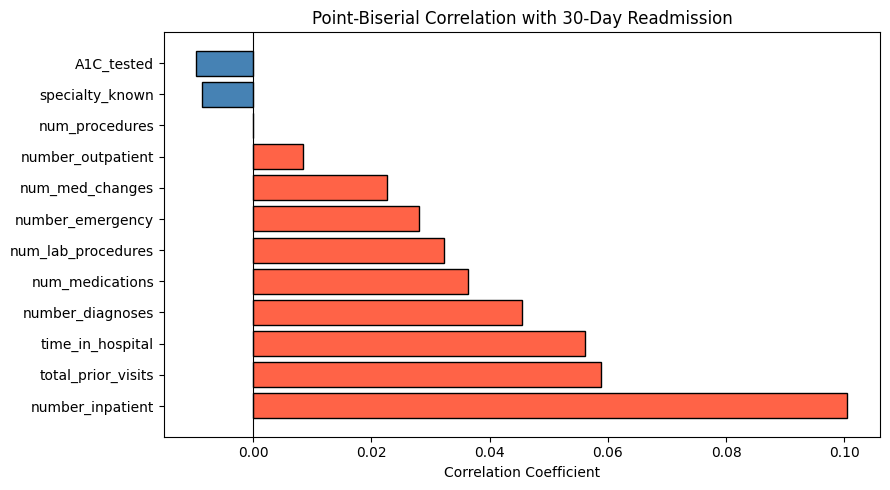

In [24]:
plt.figure(figsize=(9, 5))
vals = pb_df['Correlation'].astype(float)
colors = ['tomato' if v > 0 else 'steelblue' for v in vals]
plt.barh(pb_df.index, vals, color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Point-Biserial Correlation with 30-Day Readmission')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

Point-biserial correlation is the appropriate test when one variable is continuous and the other is binary. It is mathematically equivalent to Pearson correlation in this case but it is the formally correct choice for a binary target. We use this instead of Spearman because our features are mostly continuous or count-based, not ranked.

Key findings from the ranked table:

- number_inpatient (0.1005) is the strongest predictor. It is statistically significant (p < 0.05) and positive, meaning more prior inpatient visits increases readmission risk.
- total_prior_visits (0.0588) is second but as discussed it is partly driven by number_inpatient.
- time_in_hospital (0.0561) and number_diagnoses (0.0454) are significant positive predictors.
- num_procedures (-0.0001) is the only feature with essentially zero correlation and is the only non-significant feature (p = 0.969). This confirms the earlier observation that procedures done during this visit carry no readmission signal.
- specialty_known (-0.0086) and A1C_tested (-0.0096) are slightly negative. Having a specialist involved or having HbA1c tested is weakly associated with lower readmission. The effect is very small but statistically significant due to the large sample size.

All correlations are small in magnitude. No single numerical feature is a strong predictor on its own. This is normal for clinical tabular data and is why we use multiple features combined in a model.

### Cramer's V - Categorical Features vs Target

In [25]:
def cramers_v(col):
    ct = pd.crosstab(df[col], df['readmitted'])
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    return round(np.sqrt(chi2 / (n * (min(ct.shape) - 1))), 4)

cv_results = {col: cramers_v(col) for col in cat_cols}
cv_series = pd.Series(cv_results).sort_values(ascending=False)
print("Cramer's V - Categorical Feature Association with Readmission:")
print(cv_series)

Cramer's V - Categorical Feature Association with Readmission:
discharge_disposition_id    0.1375
age_group                   0.0467
diag_1                      0.0333
insulin                     0.0269
admission_source_id         0.0169
admission_type_id           0.0164
race                        0.0123
A1Cresult                   0.0102
max_glu_serum               0.0100
gender                      0.0030
dtype: float64


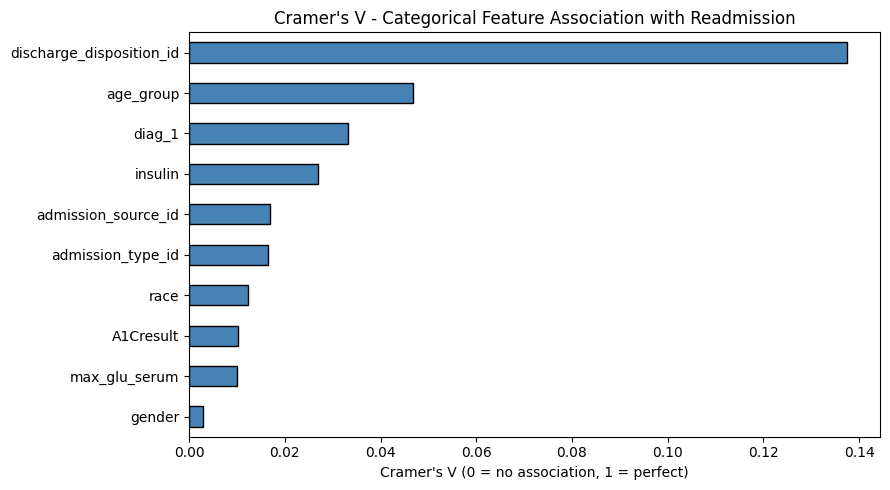

In [26]:
plt.figure(figsize=(9, 5))
cv_series.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title("Cramer's V - Categorical Feature Association with Readmission")
plt.xlabel("Cramer's V (0 = no association, 1 = perfect)")
plt.tight_layout()
plt.show()

Cramer's V is the appropriate test for association between two categorical variables. Since our target (readmitted) is binary categorical and our features are multi-category categorical, Cramer's V is the correct choice over Pearson or point-biserial which require numerical variables. It is based on the chi-squared statistic and ranges from 0 (no association) to 1 (perfect association).

Results ranked:

- discharge_disposition_id (0.1375) is by far the strongest categorical predictor. This matches the bivariate analysis showing dramatic rate differences across disposition types.
- age_group (0.0467) is second. Senior patients being above the baseline drives this association.
- diag_1 (0.0333) is third. The Diabetes primary group at 5% vs Injury at 10.78% creates this signal.
- insulin (0.0269) is fourth. Patients with active dosage changes (Up or Down) are above the baseline.
- admission_source_id (0.0169) and admission_type_id (0.0164) show small but present associations. The source and type of admission carry some information about patient severity.
- race (0.0123) is weak but non-zero. This will matter for the fairness analysis.
- A1Cresult (0.0102) and max_glu_serum (0.0100) are near the bottom which is consistent with the bivariate analysis showing very similar rates across all their groups.
- gender (0.0030) is essentially zero. Gender has almost no association with readmission in this dataset.

All Cramer's V values are small. This is consistent with the numerical correlations. No single feature is a dominant predictor. The model will need to combine many weak signals.

### Key Insights

1. The dataset has a 9% positive class rate. Accuracy is not a valid metric. All models in Notebook 03 will be evaluated using AUC, F1-score and Recall.

2. number_inpatient is the strongest numerical predictor with a point-biserial correlation of 0.1005 and a 135% higher mean in the readmitted group. This is consistent with the paper's finding. num_procedures is the weakest with essentially zero correlation (p = 0.969, not significant) and is a candidate for dropping in Notebook 03.

3. 81.6% of patients had no HbA1c test done (A1Cresult = None), directly confirming the paper's finding of 18.4% testing frequency. The None group has a readmission rate of 9.10%, slightly higher than all three tested groups (8.63%, 8.59%, 8.16%). A1Cresult alone is a weak predictor with a Cramer's V of 0.0102.

4. Diabetes as a primary diagnosis has the lowest readmission rate at 5.0%, well below the 9% baseline. This supports the paper's finding that diabetes-primary patients receive more focused diabetic care. Injury patients have the highest rate at 10.78%.

5. discharge_disposition_id is the strongest categorical predictor with a Cramer's V of 0.1375. ID 1 (home discharge, 44,317 patients) has a 6.9% rate. ID 3 (skilled nursing, 8,784 patients) has 13.4%. gender is the weakest predictor with a Cramer's V of 0.0030.

6. No single feature is a strong predictor. All correlations and associations are small in magnitude. The model in Notebook 03 will combine many weak signals. This also means the IBCAST fairness analysis will be important: with weak overall signals, racial bias in model predictions is more likely to emerge even when raw readmission rates across racial groups look similar.